## Amazon Sales Data Analysis using Python

##### This project analyzes Amazon sales data to understand revenue trends, product performance, customer behavior, and payment patterns using Pandas, NumPy, and Matplotlib.

##### Import Libraries  
Imports all required Python libraries (Pandas, NumPy, Matplotlib, etc.) needed for data analysis and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Load Dataset 
Loads the dataset file into a pandas DataFrame for analysis. 

In [ ]:
df = pd.read_csv("amazon_sales.csv")

##### Display DataFrame 
Shows the dataset stored in df to view the table of data. 

In [ ]:
df

##### Dataset Shape 
Returns the number of rows and columns in the dataset. 

In [ ]:
df.shape

##### Column Names 
Displays the names of all columns present in the dataset.

In [ ]:
df.columns

##### Data Types 
Shows the data type of each column in the dataset.

In [ ]:
df.dtypes

##### Object Type 
Shows the type of object stored in df (Pandas DataFrame).

In [ ]:
type(df)

##### First Rows Preview 
Displays the first 5 rows of the dataset.

In [ ]:
df.head()

##### Last Rows Preview 
Displays the last 5 rows of the dataset.

In [ ]:
df.tail()

##### Dataset Information 
Displays dataset details including index range, column names, non-null counts, data types of each column, overall dataset type, and memory usage.

In [ ]:
df.info()

##### Statistical Summary 
Displays descriptive statistics (count, mean, std, min, max, quartiles) for numerical columns in the dataset.

In [ ]:
df.describe()

##### Check Missing Values 
Identifies missing (null) values in the dataset.

In [ ]:
pd.isnull(df)

##### Missing Values Count 
Counts the total number of missing (null) values in each column of the dataset.

In [ ]:
pd.isnull(df).sum()

##### Duplicate Rows Count 
Returns the total number of duplicate rows present in the dataset.

In [ ]:
df.duplicated().sum()

##### Remove Duplicate Rows 
Deletes duplicate rows from the dataset and updates the DataFrame in place.

In [ ]:
df.drop_duplicates(inplace=True)

##### Convert Date Column 
Converts the order_date column to datetime format for proper date-based analysis.

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])

##### Extract Year and Month 
Creates new year and month columns from the order_date for time-based analysis.

In [ ]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

##### Filter Electronics Data 
Displays only the rows where the product category is Electronics.

In [ ]:
df[df["product_category"] == "Electronics"]

##### Sort by Total Revenue 
Sorts the dataset in descending order based on the total_revenue column.

In [ ]:
df.sort_values(by="total_revenue", ascending=False)

##### Revenue Metrics 
Prints the mean, maximum, minimum, and total of the total_revenue column.

In [ ]:
print(df["total_revenue"].mean())
print(df["total_revenue"].max())
print(df["total_revenue"].min())
print(df["total_revenue"].sum())

##### Payment Method Frequency 
Shows how many times each payment method appears in the dataset.

In [ ]:
df["payment_method"].value_counts()

##### Sort by Revenue 
Sorts the dataset in descending order based on total_revenue.

In [ ]:
df.sort_values(by="total_revenue", ascending=False)

##### Region-wise Profit 
Groups the data by customer_region and calculates the total profit for each region.

In [ ]:
df.groupby("customer_region")["profit"].sum()

##### Category-wise Revenue 
Groups the data by product_category and calculates the total revenue for each category.

In [ ]:
category_sales = df.groupby("product_category")["total_revenue"].sum()
category_sales

##### Region-wise Revenue 
Groups the data by customer_region and calculates the total revenue generated from each region.

In [ ]:
region_sales = df.groupby("customer_region")["total_revenue"].sum()
region_sales

##### Payment Method Count 
Counts how many times each payment method appears in the dataset.

In [ ]:
payment_count = df["payment_method"].value_counts()
payment_count

##### Average Rating by Category 
Calculates the average rating for each product category.

In [ ]:
avg_rating = df.groupby("product_category")["rating"].mean()
avg_rating

##### Selected Columns View 
Displays only the discount_percent and total_revenue columns from the dataset.

In [ ]:
df[["discount_percent","total_revenue"]]


##### Category Revenue Bar Chart 
Creates a bar chart to visualize total revenue for each product category.

In [ ]:
category_sales.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.show()

##### Region Sales Bar Chart 
Creates a bar chart to visualize total revenue generated from each region.

In [ ]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.show()

##### Customized Payment Distribution Chart 
Creates a colored pie chart to show the percentage distribution of each payment method.

In [ ]:
colors = ["lightblue", "lightgreen", "lightcoral", "plum", "lightpink"]
payment_count.plot(kind="pie", autopct="%1.1f%%",colors=colors)
plt.title("Payment method distribution")
plt.show()

##### Donut Chart for Payment Methods 
Creates a donut chart to visualize the percentage distribution of different payment methods.

In [ ]:
colors = ["lightblue", "lightgreen", "lightcoral", "plum", "lightpink"]

payment_count.plot(kind="pie", autopct="%1.1f%%", colors=colors)

centre_circle = plt.Circle((0,0),0.50,fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Payment Method Distribution")
plt.show()

##### Discount vs Revenue Scatter Plot 
Creates a scatter plot to show the relationship between discount percentage and total revenue for each product category.

In [ ]:
categories = df["product_category"].unique()

for cat in categories:
    data = df[df["product_category"] == cat]
    plt.scatter(data["discount_percent"], data["total_revenue"], label=cat)

plt.xlabel("Discount Percent")
plt.ylabel("Total Revenue")
plt.title("Discount vs Revenue by Category")

plt.legend(title="Category")

plt.show()

##### Monthly Sales Trend 
Groups revenue by month and plots a line chart to show how sales change over time.

In [ ]:
monthly_sales = df.groupby("month")["total_revenue"].sum()

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

##### Profit by Category 
Groups data by product category and plots a bar chart of total profit for each category.

In [ ]:
profit_category = df.groupby("product_category")["profit"].sum()

profit_category.plot(kind="bar")
plt.title("Profit by Category")
plt.show()

##### Correlation Heatmap 
Displays a heatmap showing the correlation between numerical columns in the dataset.

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

##### Top Products by Revenue 
Identifies the top 10 products with the highest total revenue and displays them in a bar chart.

In [ ]:
top_products = df.groupby("product_id")["total_revenue"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.show()

##### Discount vs Profit Scatter Plot 
Plots a scatter chart to show the relationship between discount percentage and profit.

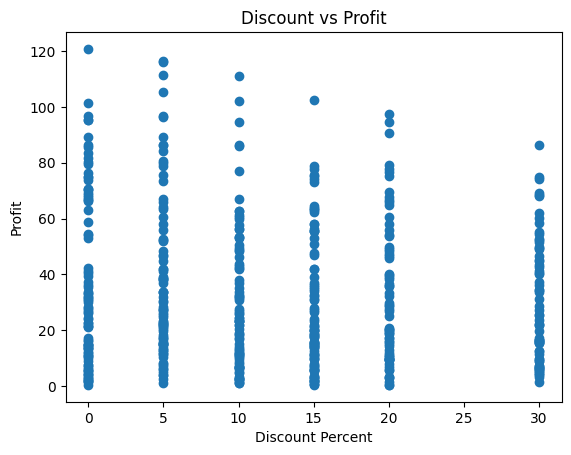

In [44]:
plt.scatter(df["discount_percent"], df["profit"])
plt.xlabel("Discount Percent")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

##### Rating vs Revenue Scatter Plot 
Plots a scatter chart to show the relationship between product ratings and total revenue.

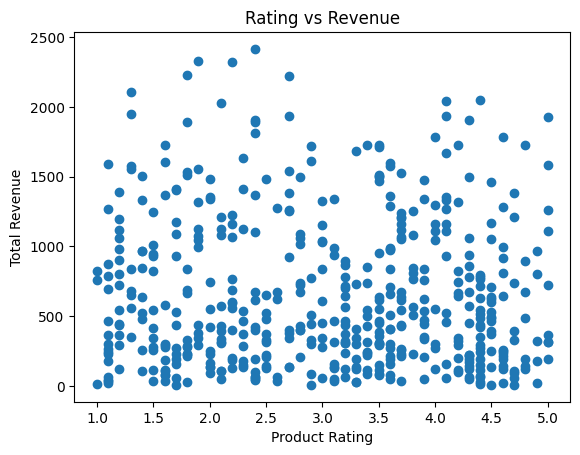

In [45]:
plt.scatter(df["rating"], df["total_revenue"])
plt.xlabel("Product Rating")
plt.ylabel("Total Revenue")
plt.title("Rating vs Revenue")
plt.show()

##### Quantity Sold by Category 
Groups data by product category and plots a bar chart of total quantity sold for each category.

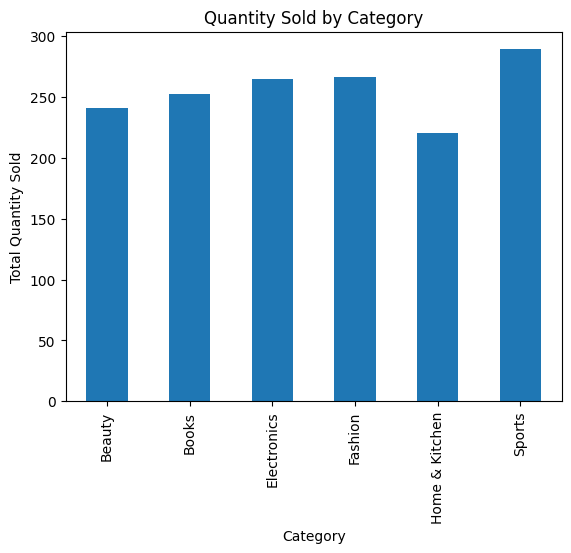

In [47]:
category_quantity = df.groupby("product_category")["quantity_sold"].sum()

category_quantity.plot(kind="bar")
plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity Sold")
plt.show()

##### Average Rating by Category Chart 
Plots a bar chart showing the average product rating for each category.

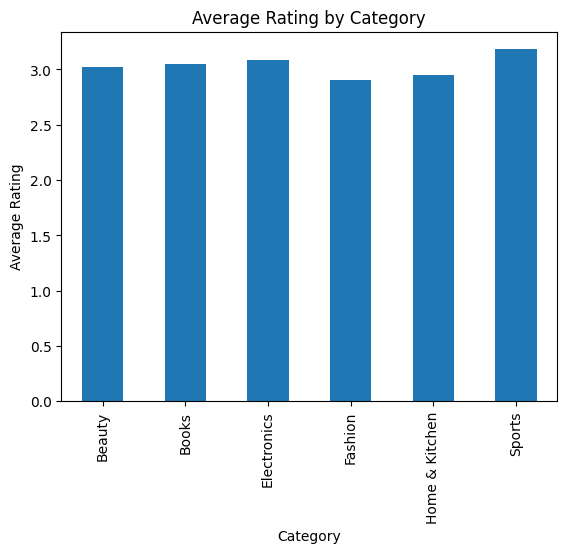

In [48]:
avg_rating = df.groupby("product_category")["rating"].mean()

avg_rating.plot(kind="bar")
plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.show()

Key Insights:

• Sports and Electronics categories generate high revenue.

• North America contributes the highest sales.

• Discounts increase product purchases but reduce profit margin.

• Credit Card and UPI are the most common payment methods.

• Some products generate significantly higher revenue than others.